In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
df_alvi = pd.read_excel('/content/drive/MyDrive/raw_data_sent_of_ner_bn/alvi.xlsx')
df_karim = pd.read_excel('/content/drive/MyDrive/raw_data_sent_of_ner_bn/karim.xlsx')[:40000]
df_rifat = pd.read_excel('/content/drive/MyDrive/raw_data_sent_of_ner_bn/rifat.xlsx')
df_test = pd.read_excel('/content/drive/MyDrive/raw_data_sent_of_ner_bn/test.xlsx')

In [ ]:
# df = pd.concat([df_alvi,df_test])

In [ ]:
def pca_dataset(df):
  documents = df.Data.values.astype(str)
  X = CountVectorizer().fit_transform(documents).todense()
  pca = PCA(n_components=2).fit(X)
  data2D = pca.transform(X)
  return data2D

In [ ]:
df_alvi_pca = pca_dataset(df_alvi)
df_karim_pca = pca_dataset(df_karim)
df_rifat_pca = pca_dataset(df_rifat)
df_test_pca = pca_dataset(df_test)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:598: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:598: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:598: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn

In [ ]:
def kmeans_dataset(df):
  documents = df.Data.values.astype(str)
  X = CountVectorizer().fit_transform(documents).todense()
  pca = PCA(n_components=2).fit(X)
  kmeans = KMeans(n_clusters=2).fit(X)
  centers2D = pca.transform(kmeans.cluster_centers_)
  return centers2D

In [ ]:
df_alvi_kmns = kmeans_dataset(df_alvi)
df_karim_kmns = kmeans_dataset(df_karim)
df_rifat_kmns = kmeans_dataset(df_rifat)
df_test_kmns = kmeans_dataset(df_test)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:598: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:598: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:598: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn

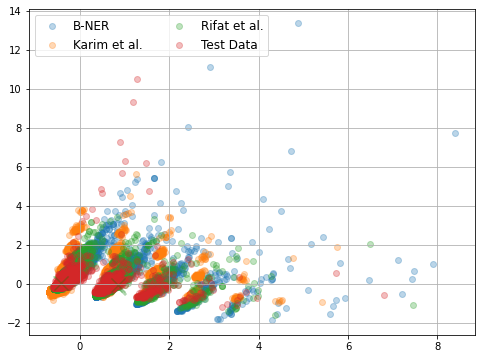

In [ ]:
alvi = plt.scatter(df_alvi_pca[:,0], df_alvi_pca[:,1], alpha=0.3)
plt.scatter(df_alvi_kmns[:,0], df_alvi_kmns[:,1], 
            marker='x', s=200, linewidths=3, c='g', alpha=0.3)
karim = plt.scatter(df_karim_pca[:,0], df_karim_pca[:,1], alpha=0.3)
plt.scatter(df_karim_kmns[:,0], df_karim_kmns[:,1], 
            marker='x', s=200, linewidths=3, c='g', alpha=0.3)
rifat = plt.scatter(df_rifat_pca[:,0], df_rifat_pca[:,1], alpha=0.3)
plt.scatter(df_rifat_kmns[:,0], df_rifat_kmns[:,1], 
            marker='x', s=200, linewidths=3, c='g', alpha=0.3)
test = plt.scatter(df_test_pca[:,0], df_test_pca[:,1], alpha=0.3)
plt.scatter(df_test_kmns[:,0], df_test_kmns[:,1], 
            marker='x', s=200, linewidths=3, c='g', alpha=0.3)
# legend_properties = {'weight':'bold'}
plt.legend((alvi, karim, rifat, test),
           ('B-NER', 'Karim et al.', 'Rifat et al.', 'Test Data'),
           scatterpoints=1,
           loc='upper left',
           ncol=2,
           fontsize=12)
# plt.legend(prop=legend_properties)
plt.grid()
plt.savefig('filename.png', dpi=1200)
# plt.rcParams["figure.figsize"] = (8, 6)
plt.show()

In [ ]:
plt.savefig('filename.pdf')

<Figure size 432x288 with 0 Axes>

In [ ]:
plt.rcParams["figure.figsize"] = (8, 6)
plt.show()